In [ ]:
pip install qiskit-nature pyscf qiskit==1.4.5 qiskit-ibm-runtime qiskit-aer pylatexenc

  Using cached qiskit_nature-0.7.2-py3-none-any.whl.metadata (8.0 kB)
  Using cached pyscf-2.12.1-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
  Using cached qiskit-1.4.5-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached qiskit_ibm_runtime-0.45.1-py3-none-any.whl.metadata (21 kB)
  Using cached qiskit_aer-0.17.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.3 kB)
  Using cached pylatexenc-2.10.tar.gz (162 kB)
  Preparing metadata (setup.py) ... done
  Using cached rustworkx-0.17.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
  Using cached stevedore-5.7.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached symengine-0.13.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached qiskit_algorithms-0.4.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached requests_ntlm-1.3.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached ibm_platform_

In [ ]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver

driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)

In [ ]:
problem = driver.run()
print(problem)
print(problem.reference_energy)
hamiltonian = problem.hamiltonian
print(hamiltonian)

-1.116998996754004


In [ ]:
from qiskit_nature.second_q.mappers import JordanWignerMapper
mapper = JordanWignerMapper()

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform",token="o0HHHmjs4XqpE1a8XStoNA1St_k1lzzoYx1LYxBgxnh-")
service.active_account()
print('Available backends:')
print(service.backends(simulator=False))
backend = service.least_busy(operational=True, simulator=False)
backend.name

qiskit_runtime_service._discover_account:WARNING:2026-03-04 04:10:31,093: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-04 04:10:41,229: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-04 04:10:41,230: Loading instance: open-instance, plan: open


Available backends:
[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


qiskit_runtime_service.backends:WARNING:2026-03-04 04:10:48,150: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-04 04:10:59,720: Using instance: open-instance, plan: open


'ibm_fez'

In [ ]:
# We will start by using a local simulator
from qiskit_aer import AerSimulator

# Import an estimator, this time from qiskit (we will import from Runtime for real hardware)
from qiskit.primitives import BackendEstimatorV2

# generate a simulator that mimics the real quantum system
backend_sim = AerSimulator.from_backend(backend)
estimator = BackendEstimatorV2(backend=backend_sim)

In [ ]:
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
ansatz = UCCSD(
    problem.num_spatial_orbitals,
    problem.num_particles,
    mapper,
    initial_state=HartreeFock(
        problem.num_spatial_orbitals,
        problem.num_particles,
        mapper,
    ),
)

4


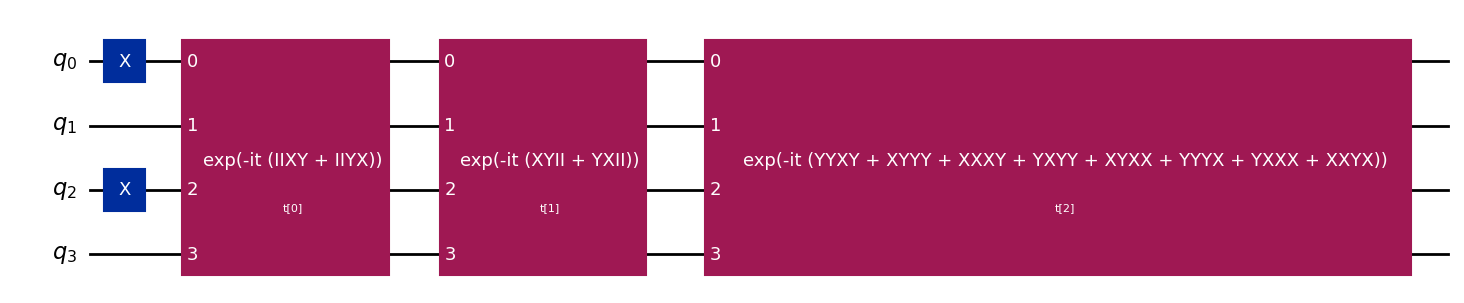

In [ ]:
print(ansatz.decompose().depth())
ansatz.decompose().draw("mpl")

In [ ]:
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import StatevectorEstimator

vqe_solver = VQE(estimator, ansatz, COBYLA())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters
x0 = vqe_solver.initial_point

from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_nature.second_q.algorithms import GroundStateEigensolver

solver = GroundStateEigensolver(mapper, vqe_solver)

In [ ]:
main_operator, aux_ops = solver.get_qubit_operators(problem)
print(main_operator)

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'ZIII', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.12091263+0.j,
  0.17218393+0.j,  0.16892754+0.j, -0.22575349+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])


In [ ]:
def cost_func(params, ansatz, H, estimator):
    pub = (ansatz, [H], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = result[0].data.evs[0]
    return energy


In [ ]:
from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
ansatz_isa = pm.run(ansatz)
H = main_operator
hamiltonian_isa = H.apply_layout(ansatz_isa.layout);

ERROR:stevedore.extension:Could not load 'ibm_backend': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/passes/utils/remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_and_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/passes/utils/remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_circuits': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/passes/utils/remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qi

In [ ]:
print(hamiltonian_isa)
print(ansatz_isa.decompose().depth())
#ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIZIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIZIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIII

In [ ]:
from scipy.optimize import minimize
from time import time
start_time = time()
results = minimize(
    cost_func,
    x0,
    args=(ansatz_isa, hamiltonian_isa, estimator),
    method="cobyla",
    options={"maxiter": 50, "disp": True},
)
optimizer_time = time()-start_time()
print(f"Optimizer time: {optimizer_time}")

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 33   Least value of F = -1.7171400695583385
The corresponding X is:
[-0.05933434 -0.03677148 -0.12168509]

Optimizer time: -130.77662181854248


In [ ]:
nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy
print(f"Nuclear Repulsion Energy = {nuclear_repulsion}")
print("Ground state energy")
print(getattr(results, "fun") + nuclear_repulsion)
print(results)

Nuclear Repulsion Energy = 0.7199689944489797
Ground state energy
-0.9971710751093589
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.7171400695583385
       x: [-5.933e-02 -3.677e-02 -1.217e-01]
    nfev: 33
   maxcv: 0.0


In [ ]:
print(problem.num_spatial_orbitals)
print(problem.num_particles)

2
(1, 1)


In [ ]:
import numpy as np
import pandas as pd

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit

# Bond lengths in Angstrom
bond_lengths = np.linspace(0.25, 1.5, 21)



from qiskit_nature.second_q.mappers import JordanWignerMapper
mapper = JordanWignerMapper()

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform",token="o0HHHmjs4XqpE1a8XStoNA1St_k1lzzoYx1LYxBgxnh-")
service.active_account()
print('Available backends:')
print(service.backends(simulator=False))
backend = service.least_busy(operational=True, simulator=False)
print(f"Backend = {backend.name}")

# We will start by using a local simulator
from qiskit_aer import AerSimulator

# Import an estimator, this time from qiskit (we will import from Runtime for real hardware)
from qiskit.primitives import BackendEstimatorV2

# generate a simulator that mimics the real quantum system
backend_sim = AerSimulator.from_backend(backend)
estimator = BackendEstimatorV2(backend=backend_sim)

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from scipy.optimize import minimize

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from time import time


energies = []
ground_energies = []
optimizer_times = []
iteration_number = []
optimizer_results = []
nuclear_repulsion_energies = []


for r in bond_lengths:
    # Define H2 geometry
    geometry = f"H 0 0 0; H 0 0 {r}"

    # PySCF driver
    driver = PySCFDriver(
        atom=geometry,
        basis="sto3g",
        spin=0,
        charge=0,
        unit=DistanceUnit.ANGSTROM,
    )

    # Run electronic structure calculation
    problem = driver.run()
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy

    ansatz = UCCSD(
        problem.num_spatial_orbitals,
        problem.num_particles,
        mapper,
        initial_state=HartreeFock(
            problem.num_spatial_orbitals,
            problem.num_particles,
            mapper,),
        )

    vqe_solver = VQE(AerEstimator, ansatz, COBYLA())
    vqe_solver.initial_point = [0.0] * ansatz.num_parameters
    x0 = vqe_solver.initial_point

    solver = GroundStateEigensolver(mapper, vqe_solver)

    main_operator, aux_ops = solver.get_qubit_operators(problem)


    target = backend.target
    pm = generate_preset_pass_manager(target=target, optimization_level=3)
    ansatz_isa = pm.run(ansatz)
    H = main_operator
    hamiltonian_isa = H.apply_layout(ansatz_isa.layout);

    start_time = time()
    result = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
        options={"maxiter": 50, "disp": True},)

    optimizer_time = start_time - time()
    energy = result.fun
    ground_state_energy = energy + nuclear_repulsion


    energies.append(energy)
    ground_energies.append(ground_state_energy)
    optimizer_results.append(result)
    optimizer_times.append(optimizer_time)
    nuclear_repulsion_energies.append(nuclear_repulsion)



# Create table
df = pd.DataFrame({
    "Bond Length (Å)": bond_lengths,
    "Results": optimizer_results,
    "Ground State Energy (Hartree)": ground_energies,
    "Time (s)": optimizer_times,
    "Nuclear Repulsion Energy (Hartree)": nuclear_repulsion_energies,
    "Electronic Energies (Hartree)": energies
})
print(df)
import matplotlib.pyplot as plt

plt.plot(bond_lengths, energies, marker='o')
plt.xlabel("Bond Length (Å)")
plt.ylabel("Energy (Hartree)")
plt.title("Classical: H₂ Ground-State Energy vs Bond Length (STO-3G)")
plt.grid(True)
plt.show()
